## NLP

In [2]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

In [3]:
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Videep\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Videep\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [4]:
df = pd.read_csv('19 blogs.csv')
df.head()

,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism


In [5]:
df.shape

(2000, 2)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Data    2000 non-null   str  
 1   Labels  2000 non-null   str  
dtypes: str(2)
memory usage: 4.5 MB


In [7]:
df['Labels'].value_counts()

Labels
alt.atheism                 100
comp.graphics               100
comp.os.ms-windows.misc     100
comp.sys.ibm.pc.hardware    100
comp.sys.mac.hardware       100
comp.windows.x              100
misc.forsale                100
rec.autos                   100
rec.motorcycles             100
rec.sport.baseball          100
rec.sport.hockey            100
sci.crypt                   100
sci.electronics             100
sci.med                     100
sci.space                   100
soc.religion.christian      100
talk.politics.guns          100
talk.politics.mideast       100
talk.politics.misc          100
talk.religion.misc          100
Name: count, dtype: int64

In [8]:
df.isnull().sum()

Data      0
Labels    0
dtype: int64

In [9]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = [w for w in text.split() if w not in stop_words]
    return ' '.join(words)

df['Clean_Text'] = df['Data'].apply(clean_text)
df[['Data','Clean_Text']].head()

,Data,Clean_Text
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,path cantaloupe srv cs cmu edu magnesium club ...
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,newsgroups alt atheism path cantaloupe srv cs ...
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,path cantaloupe srv cs cmu edu das news harvar...
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,path cantaloupe srv cs cmu edu magnesium club ...
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,xref cantaloupe srv cs cmu edu alt atheism tal...


* All blog posts are converted to lowercase to maintain consistency.
* Punctuation and special characters were removed from the text.
* Stopwords were removed to eliminate common words that do not contribute much to classification.
* The cleaned text is more suitable for feature extraction using TF-IDF.

In [10]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['Clean_Text'])
y = df['Labels']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
#multinomial Naive Bayes
model = MultinomialNB()
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [12]:
accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred, average='weighted')
recall = recall_score(y_test, pred, average='weighted')
f1 = f1_score(y_test, pred, average='weighted')

In [13]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.83
Precision: 0.8359823374360493
Recall   : 0.83
F1 Score : 0.8265975456230247


In [14]:
print(classification_report(y_test, pred))

                          precision    recall  f1-score   support

             alt.atheism       0.86      0.60      0.71        20
           comp.graphics       0.74      0.85      0.79        20
 comp.os.ms-windows.misc       0.80      1.00      0.89        20
comp.sys.ibm.pc.hardware       0.68      0.85      0.76        20
   comp.sys.mac.hardware       0.94      0.75      0.83        20
          comp.windows.x       0.87      0.65      0.74        20
            misc.forsale       0.86      0.90      0.88        20
               rec.autos       0.80      1.00      0.89        20
         rec.motorcycles       0.89      0.80      0.84        20
      rec.sport.baseball       0.95      0.90      0.92        20
        rec.sport.hockey       0.87      1.00      0.93        20
               sci.crypt       0.95      1.00      0.98        20
         sci.electronics       0.87      0.65      0.74        20
                 sci.med       0.94      0.80      0.86        20
         

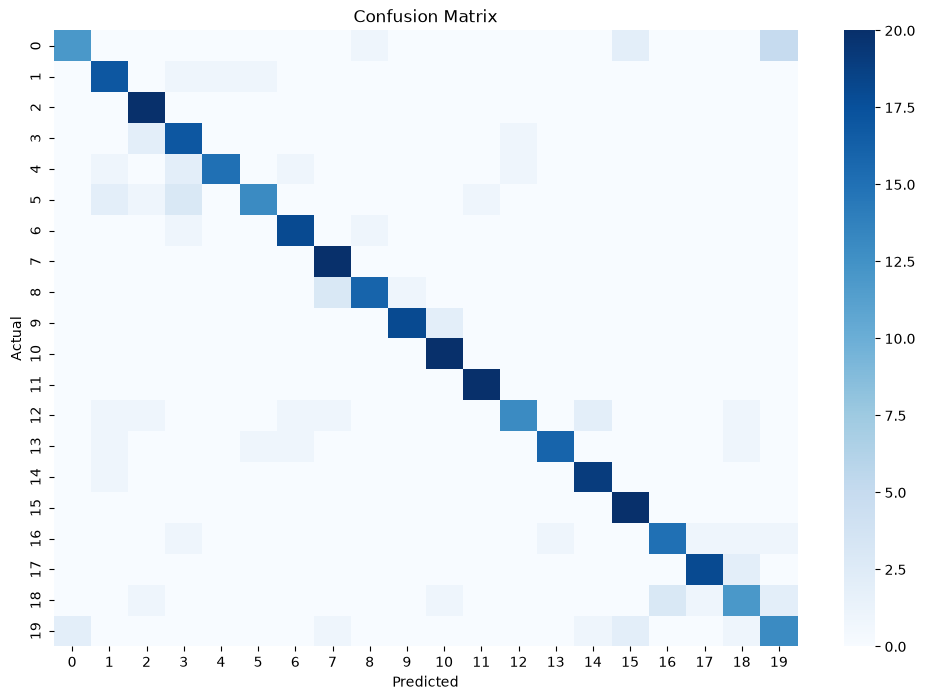

In [15]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(12,8))
sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix has a strong diagonal, showing that most blog posts were classified correctly. Only a few misclassifications are present, mainly due to similar words appearing across different categories. This indicates good performance of the Multinomial Naive Bayes model.

In [16]:
sia = SentimentIntensityAnalyzer()

def sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    return 'Neutral'

df['Sentiment'] = df['Data'].apply(sentiment)
df[['Data','Sentiment']].head()

,Data,Sentiment
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,Negative
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,Positive
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,Negative
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,Negative
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,Positive


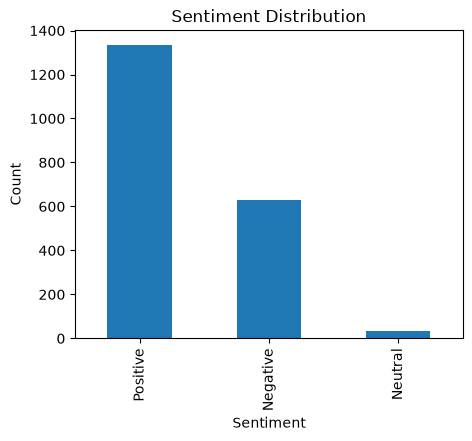

In [17]:
sentiment_counts = df['Sentiment'].value_counts()
plt.figure(figsize=(5,4))
sentiment_counts.plot(kind='bar')
plt.title("Sentiment Distribution")
plt.ylabel("Count")
plt.show()

* Positive sentiment is the most common in the dataset, indicating that most blog posts express an optimistic or favorable tone.
* Negative sentiment is the second most frequent, suggesting that a considerable number of blogs discuss criticism, concerns, or negative experiences.
* Neutral sentiment is very rare, showing that most blog posts contain clear emotional expressions rather than objective statements.

In [18]:
category_sentiment = pd.crosstab(df['Labels'], df['Sentiment'])
print(category_sentiment)

Sentiment                 Negative  Neutral  Positive
Labels                                               
alt.atheism                     42        1        57
comp.graphics                   13        4        83
comp.os.ms-windows.misc         24        2        74
comp.sys.ibm.pc.hardware        21        0        79
comp.sys.mac.hardware           24        3        73
comp.windows.x                  20        2        78
misc.forsale                     7        8        85
rec.autos                       27        1        72
rec.motorcycles                 30        2        68
rec.sport.baseball              27        1        72
rec.sport.hockey                28        1        71
sci.crypt                       29        0        71
sci.electronics                 18        4        78
sci.med                         38        1        61
sci.space                       32        3        65
soc.religion.christian          29        0        71
talk.politics.guns          